# Stage 07: Outliers, Risk, and Assumptions

This submission detects return outliers with IQR and Z-score rules and compares regression sensitivity for all, filtered, and winsorized data.

## Setup — Generate the Provided Dataset

The starter's fixed seed and shock values are retained exactly so the analysis is reproducible.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.outliers import detect_outliers_iqr, detect_outliers_zscore, winsorize_series

RAW_PATH = PROJECT_ROOT / "data/raw/outliers_homework.csv"
RAW_PATH.parent.mkdir(parents=True, exist_ok=True)
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")
np.random.seed(17)
returns = np.random.normal(0, 0.01, size=len(dates))
returns[dates < "2022-05-01"] -= 0.0015
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294,
}
for date, value in shock_values.items():
    returns[np.where(dates == pd.Timestamp(date))[0][0]] = value
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))
generated_df = pd.DataFrame({"date": dates, "daily_return": returns, "daily_return_2": daily_return_2})
generated_df.to_csv(RAW_PATH, index=False)
print("Saved generated data:", RAW_PATH.relative_to(PROJECT_ROOT))
print("Shape:", generated_df.shape)

Matplotlib is building the font cache; this may take a moment.


Saved generated data: data/raw/outliers_homework.csv
Shape: (115, 3)


## Load Data and Apply Outlier Flags

In [2]:
df = pd.read_csv(RAW_PATH, parse_dates=["date"])
target_column = "daily_return"
response_column = "daily_return_2"
df["outlier_iqr"] = detect_outliers_iqr(df[target_column], k=1.5)
df["outlier_zscore"] = detect_outliers_zscore(df[target_column], threshold=3.0)
flag_comparison = pd.DataFrame({
    "flagged_count": df[["outlier_iqr", "outlier_zscore"]].sum(),
    "flagged_fraction": df[["outlier_iqr", "outlier_zscore"]].mean(),
})
display(flag_comparison)
print("Flags agree on all rows:", df["outlier_iqr"].equals(df["outlier_zscore"]))
display(df.loc[df["outlier_iqr"], ["date", target_column, response_column]])

,flagged_count,flagged_fraction
outlier_iqr,9,0.078261
outlier_zscore,5,0.043478


Flags agree on all rows: False


,date,daily_return,daily_return_2
41,2022-03-01,0.031952,0.023944
63,2022-03-31,-0.031101,-0.020710
85,2022-05-02,0.174843,0.112930
86,2022-05-03,-0.168258,-0.095461
87,2022-05-04,-0.033999,-0.028415
89,2022-05-06,-0.196672,-0.115209
90,2022-05-09,0.212402,0.136536
92,2022-05-11,0.028711,0.017664
93,2022-05-12,-0.178729,-0.100548


## Treatments and Summary Sensitivity

Filtering removes rows flagged by the 1.5×IQR rule. Winsorizing keeps every row but clips both numeric variables to their 5th and 95th percentiles.

In [3]:
all_df = df[[target_column, response_column]].copy()
filtered_df = df.loc[~df["outlier_iqr"], [target_column, response_column]].copy()
winsorized_df = all_df.copy()
for column in [target_column, response_column]:
    winsorized_df[column] = winsorize_series(winsorized_df[column], lower=0.05, upper=0.95)

summary_comparison = pd.DataFrame({
    "all": all_df[target_column].agg(["mean", "median", "std"]),
    "filtered_iqr": filtered_df[target_column].agg(["mean", "median", "std"]),
    "winsorized": winsorized_df[target_column].agg(["mean", "median", "std"]),
}).T
summary_comparison["rows"] = [len(all_df), len(filtered_df), len(winsorized_df)]
display(summary_comparison)

,mean,median,std,rows
all,-0.001434,-0.000187,0.040579,115
filtered_iqr,-0.000039,-0.000100,0.009443,106
winsorized,-0.000251,-0.000187,0.010623,115


## Boxplot Before and After Treatment

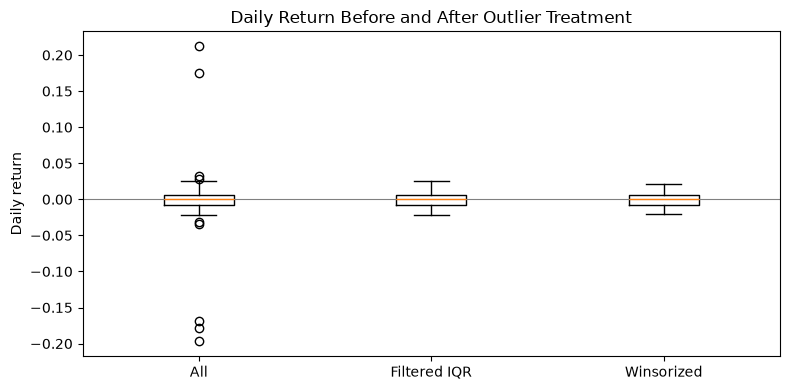

In [4]:
figure, axis = plt.subplots(figsize=(8, 4))
axis.boxplot([all_df[target_column], filtered_df[target_column], winsorized_df[target_column]],
             tick_labels=["All", "Filtered IQR", "Winsorized"])
axis.set(title="Daily Return Before and After Outlier Treatment", ylabel="Daily return")
axis.axhline(0, color="gray", linewidth=0.8)
figure.tight_layout()
plt.show()

## Regression Sensitivity Analysis

For each treatment, `daily_return_2` is regressed on `daily_return`. Metrics are in-sample and describe sensitivity rather than future predictive performance.

In [5]:
def fit_variant(data, label):
    X = data[[target_column]]
    y = data[response_column]
    model = LinearRegression().fit(X, y)
    predictions = model.predict(X)
    metrics = {
        "variant": label, "rows": len(data), "slope": model.coef_[0],
        "intercept": model.intercept_, "r2": model.score(X, y),
        "mae": mean_absolute_error(y, predictions),
    }
    return metrics, y.to_numpy() - predictions

variants = {"all": all_df, "filtered_iqr": filtered_df, "winsorized": winsorized_df}
metrics_rows = []
residuals = {}
for label, data in variants.items():
    metrics, residual = fit_variant(data, label)
    metrics_rows.append(metrics)
    residuals[label] = residual
regression_results = pd.DataFrame(metrics_rows).set_index("variant")
display(regression_results)

,rows,slope,intercept,r2,mae
variant,,,,,
all,115,0.605869,0.000201,0.961859,0.003951
filtered_iqr,106,0.589679,-0.000049,0.573566,0.003851
winsorized,115,0.649705,-0.000017,0.689444,0.003741


## Stretch: Residual Comparison

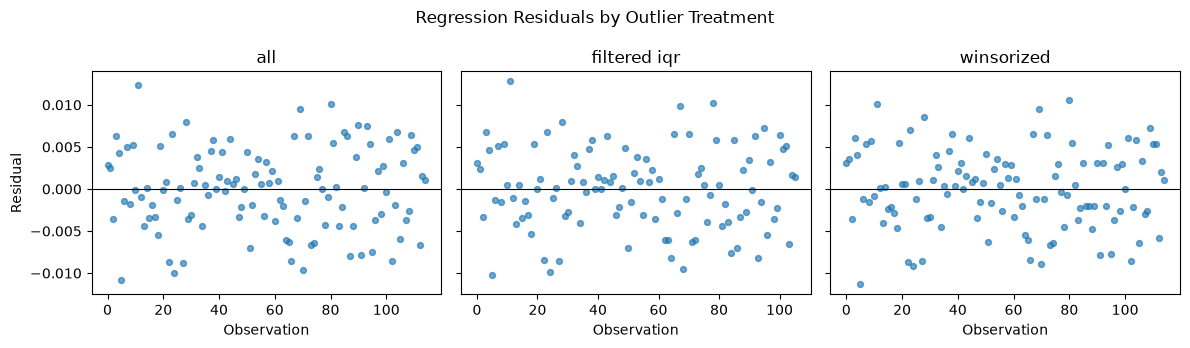

In [6]:
figure, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for axis, (label, residual) in zip(axes, residuals.items()):
    axis.scatter(np.arange(len(residual)), residual, alpha=0.65, s=18)
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_title(label.replace("_", " "))
    axis.set_xlabel("Observation")
axes[0].set_ylabel("Residual")
figure.suptitle("Regression Residuals by Outlier Treatment")
figure.tight_layout()
plt.show()

## Reflection: Methods, Assumptions, Impact, and Risk

I used the conventional 1.5×IQR rule as the primary flag because it is distribution-agnostic and appropriate for heavy-tailed return data. I also used an absolute population Z-score threshold of 3.0 as a comparison. The Z-score rule assumes the mean and standard deviation summarize the distribution reasonably well, which is questionable for financial returns and especially fragile when extreme observations inflate the standard deviation. The improved functions reject invalid thresholds and empty or nonnumeric inputs, define population standard deviation explicitly, and treat missing values as not-outliers rather than silently converting missingness into a data-quality decision.

The IQR rule flags nine rows: all five injected shocks plus four naturally generated returns, whereas the 3.0 Z-score rule flags only the five injected shocks. This disagreement shows that threshold choice can classify valid tail observations differently. The 5%/95% winsorized treatment retains every date but limits tail leverage. The median is relatively stable while standard deviation changes substantially. The all-data regression has the highest in-sample R² because the injected shocks move along the correlation between the two return columns; filtering lowers R² even though MAE changes only slightly. Therefore, removing outliers did not automatically produce a better model. The rows and response distribution differ across treatments, and these metrics are not an out-of-sample test.

The main assumption is that the extreme observations are measurement-like contamination or atypical enough that a model should not be dominated by them. In markets, that assumption can be wrong: shocks may be real, decision-relevant regime events rather than errors. Removing them could understate tail risk and make a model appear more stable than it is. Conversely, leaving errors or one-off shocks untreated can distort coefficients and average-error metrics. I would therefore preserve the raw data, retain an explicit outlier flag, report all three variants, and investigate the dates against source records and market events before selecting a production treatment. Thresholds should be re-estimated only on training data to avoid leakage, and model conclusions should be checked with time-ordered out-of-sample validation.